<a href="https://colab.research.google.com/github/jedidiahramos/DiscreteMathClustering/blob/main/GroupingLearningOutcomes_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kneed

In [ ]:
pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from google.colab import files
import json

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, OPTICS, SpectralClustering, AgglomerativeClustering, DBSCAN, MeanShift, AffinityPropagation, Birch
from sklearn.mixture import GaussianMixture
import hdbscan
import plotly.express as px
from tabulate import tabulate
from kneed import KneeLocator
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.metrics import silhouette_score
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                            v_measure_score, confusion_matrix)

In [ ]:
uploaded = files.upload()

def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

categories_and_LOs = load_data('processed_LOs.json')

Saving processed_LOs.json to processed_LOs.json


In [ ]:
data = []

for category, LOList in categories_and_LOs.items():
  for index, nested in enumerate(LOList):
    for LO in nested:
      data.append([category, index, LO])

df = pd.DataFrame(data, columns=['Category', 'Index', 'LO'])

In [ ]:
df.head(10)

,Category,Index,LO
0,"Sets, Proofs, and Induction",0,Given a description of multiple sets and their...
1,"Sets, Proofs, and Induction",0,"Given a scenario involving multiple sets, tran..."
2,"Sets, Proofs, and Induction",0,Given a collection of sets with defined proper...
3,"Sets, Proofs, and Induction",1,"Given a finite set of numbers, identify and ar..."
4,"Sets, Proofs, and Induction",1,"Given a specific set, generate multiple verbal..."
5,"Sets, Proofs, and Induction",1,"Given a set with an underlying pattern, recogn..."
6,"Sets, Proofs, and Induction",2,"Given a set with various elements, including n..."
7,"Sets, Proofs, and Induction",2,"Given a description of a set, identify whether..."
8,"Sets, Proofs, and Induction",2,"Given a set with complex nesting, analyze its ..."
9,"Sets, Proofs, and Induction",3,"Given two sets, determine whether they are equ..."


Clustering test

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def reduce_dims_pca(df, vectors, n_components=2):
  X = np.vstack(vectors)
  pca = PCA(n_components=n_components)
  X_reduced = pca.fit_transform(X)
  if n_components == 2:
    df[['x', 'y']] = X_reduced
  return X_reduced

def reduce_dims_tsne(df, vectors, n_components=2):
  X = np.vstack(vectors)
  tsne = TSNE(n_components=n_components)
  X_reduced = tsne.fit_transform(X)
  if n_components == 2:
    df[['x', 'y']] = X_reduced
  return X_reduced

def reduce_dims_umap(df, vectors, n_components=2, n_neighbors=15, min_dist=0.1):
    X = np.vstack(vectors)
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist)
    X_reduced = reducer.fit_transform(X)
    if n_components == 2:
      df[['x', 'y']] = X_reduced
    return X_reduced

def reduce_to_2d_pca_tsne(df, vectors):
  X = np.vstack(vectors)
  pca = PCA(n_components=10)
  X_reduced = pca.fit_transform(X)

  tsne = TSNE(n_components=2, random_state=0)
  X_2d = tsne.fit_transform(X_reduced)

  df[['x', 'y']] = X_2d

def visualize_plot(title, df, cluster_column):
    # Scatter plot using Plotly Express
    fig = px.scatter(df, x="x", y="y", color=cluster_column,
                     color_continuous_scale='viridis',
                     title=title,
                     labels={"x": "t-SNE Component 1", "y": "t-SNE Component 2", cluster_column: "Cluster"},
                     hover_data=["Category", "LO"])

    fig.update_traces(marker=dict(size=10))  # Adjust marker size
    fig.show()

    # Loop through each cluster and plot category distribution as a pie chart
    groups = df.groupby(cluster_column)

    for cluster, group in groups:
      # Count occurrences of each category within the cluster
      category_counts = group['Category'].value_counts().reset_index()
      category_counts.columns = ['Category', 'Count']

      # Calculate percentages for each category
      total_count = category_counts['Count'].sum()
      category_counts['Percentage'] = (category_counts['Count'] / total_count) * 100

      # Round values for prettier display
      category_counts['Percentage'] = category_counts['Percentage'].round(2)

      # Print the category distribution for the current cluster in a clean table
      print(f"\nCluster {cluster} Category Distribution:")
      print(tabulate(category_counts, headers='keys', tablefmt='fancy_grid', showindex=False))

def cluster_all_euclidean(vectors, num_clusters, df, random_state=0):
    """
    Perform clustering on document vectors, reduce dimensions, and plot clusters.

    Args:
        vectors: List of document vectors (e.g., output from vectorize function)
        num_clusters: Number of clusters for KMeans
        df: DataFrame containing the documents

    Returns:
        DataFrame with added 'cluster', 'x', and 'y' columns for visualization
    """

    # Step 1: Convert vectors to numpy array and perform KMeans clustering
    X = np.vstack(vectors)

    kmeans = KMeans(n_clusters=num_clusters, random_state=random_state)
    df["cluster_kmeans"] = kmeans.fit_predict(X)

    dbscan = DBSCAN(eps=0.1, min_samples=2)
    df["cluster_dbscan"] = dbscan.fit_predict(X)

    clustering_optics = OPTICS(min_samples=10, xi=.01, min_cluster_size=.05).fit_predict(X)
    df["cluster_optics"] = clustering_optics

    clustering_hdbscan = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True).fit_predict(X)
    df["cluster_hdbscan"] = clustering_hdbscan

    clustering_spectral = SpectralClustering(n_clusters=num_clusters, assign_labels='discretize', random_state=random_state).fit_predict(X)
    df["cluster_spectral"] = clustering_spectral

    clustering_gmm = GaussianMixture(n_components=num_clusters, random_state=random_state).fit_predict(X)
    df["cluster_gmm"] = clustering_gmm

    clustering_agglo = AgglomerativeClustering(n_clusters=num_clusters).fit_predict(X)
    df["cluster_agglo"] = clustering_agglo

    clustering_meanshift = MeanShift().fit_predict(X)
    df["cluster_meanshift"] = clustering_meanshift

    clustering_affinity = AffinityPropagation(random_state=random_state).fit_predict(X)
    df["cluster_affinity"] = clustering_affinity

    clustering_birch = Birch(n_clusters=num_clusters).fit_predict(X)
    df["cluster_birch"] = clustering_birch

def cluster_all_cosine(vectors, num_clusters, df, random_state=0):
    """
    Perform clustering using cosine similarity across multiple clustering algorithms.

    Args:
        vectors: List of document vectors (will be normalized inside)
        num_clusters: Number of clusters for algorithms that require it
        df: DataFrame to store clustering results
        eps: DBSCAN epsilon value
        min_samples: DBSCAN/OPTICS/HDBSCAN minimum samples

    Returns:
        DataFrame with cluster labels added
    """
    # Normalize input vectors for cosine similarity
    X = normalize(np.vstack(vectors), norm='l2')

    # Cosine similarity and distance matrices
    cosine_sim = cosine_similarity(X)
    cosine_dist = 1 - cosine_sim

    # Ensure cosine_dist is in double precision (double_t)
    cosine_dist = cosine_dist.astype(np.float64)  # Convert to double_t

    # KMeans (approximate cosine)
    df["cluster_kmeans"] = KMeans(n_clusters=num_clusters, random_state=random_state).fit_predict(X)

    # DBSCAN with cosine metric
    df["cluster_dbscan"] = DBSCAN(metric='cosine', eps=0.1, min_samples=2).fit_predict(X)

    # OPTICS with cosine metric
    df["cluster_optics"] = OPTICS(metric='cosine', min_samples=10, xi=0.01, min_cluster_size=0.05).fit_predict(X)

    # HDBSCAN with precomputed cosine distance
    df["cluster_hdbscan"] = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True, metric='precomputed').fit_predict(cosine_dist)

    # Spectral clustering with precomputed cosine similarity
    df["cluster_spectral"] = SpectralClustering(
        n_clusters=num_clusters,
        affinity='precomputed',
        assign_labels='discretize',
        random_state=random_state
    ).fit_predict(cosine_sim)

    # Gaussian Mixture (approximate cosine)
    df["cluster_gmm"] = GaussianMixture(n_components=num_clusters, random_state=random_state).fit_predict(X)

    # Agglomerative Clustering with cosine distance
    df["cluster_agglo"] = AgglomerativeClustering(
        n_clusters=num_clusters,
        metric='precomputed',
        linkage='average'
    ).fit(cosine_dist).labels_

    # MeanShift (approximate cosine)
    df["cluster_meanshift"] = MeanShift().fit_predict(X)

    # Affinity Propagation with precomputed cosine similarity
    df["cluster_affinity"] = AffinityPropagation(affinity='precomputed', random_state=random_state).fit_predict(cosine_sim)

    # Birch (approximate cosine)
    df["cluster_birch"] = Birch(n_clusters=num_clusters).fit_predict(X)

    return df


def visualize_all_clusters(df):
    visualize_plot("KMeans Clusters of Questions", df, "cluster_kmeans")
    visualize_plot("DBSCAN Clusters of Questions", df, "cluster_dbscan")
    visualize_plot("OPTICS Clusters of Questions", df, "cluster_optics")
    visualize_plot("HDBSCAN Clusters of Questions", df, "cluster_hdbscan")
    visualize_plot("Spectral Clusters of Questions", df, "cluster_spectral")
    visualize_plot("GMM Clusters of Questions", df, "cluster_gmm")
    visualize_plot("Agglomerative Clusters of Questions", df, "cluster_agglo")
    visualize_plot("MeanShift Clusters of Questions", df, "cluster_meanshift")
    visualize_plot("AffinityPropagation Clusters of Questions", df, "cluster_affinity")
    visualize_plot("Birch Clusters of Questions", df, "cluster_birch")

In [ ]:
def listInfo(vectors, withL2Normalization=False, random_state=42):
  if withL2Normalization:
    vectors = normalize(vectors, norm='l2')
  pca = PCA()
  X_pca = pca.fit_transform(vectors)

  explained_variance = pca.explained_variance_ratio_
  cumulative_variance = np.cumsum(explained_variance)

  # Plot to visualize how many components to keep
  plt.figure(figsize=(8, 5))
  plt.plot(cumulative_variance, marker='o')
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.grid(True)
  plt.title('Explained Variance vs Number of Components')
  plt.show()

  desired_variance = 0.99  # 95% of total variance
  n_components = np.argmax(cumulative_variance >= desired_variance) + 1
  print(f"Number of components to reach {desired_variance*100}% variance: {n_components}")

  inertias = []
  K = range(1, 21)  # Try k from 1 to 10

  for k in K:
      kmeans = KMeans(n_clusters=k, random_state=random_state)
      kmeans.fit(vectors)  # X is your feature matrix
      inertias.append(kmeans.inertia_)

  plt.plot(K, inertias, marker='o')
  plt.xlabel('Number of clusters (k)')
  plt.ylabel('Inertia')
  plt.title('Elbow Method for Optimal k')
  plt.grid(True)
  plt.show()

  kl = KneeLocator(K, inertias, curve="convex", direction="decreasing")
  optimal_k = kl.elbow
  print(f"Optimal number of clusters: {optimal_k}")

In [ ]:
def generate_dendrogram_data_euclidean(vectors):
    """Computes the linkage matrix for hierarchical clustering."""
    Z = linkage(vectors, method='ward')
    return Z

def generate_dendrogram_data_cosine(vectors):
    """Computes the linkage matrix using cosine distance for hierarchical clustering."""
    cosine_dist = pdist(vectors, metric='cosine')  # Convert similarity to distance
    Z = linkage(cosine_dist, method='average')  # Use 'average' or 'complete', not 'ward' with cosine
    return Z

def plot_dendrogram(Z, ques, cutoff=None):
    """Plots the dendrogram from the linkage matrix."""
    fig, ax = plt.subplots(figsize=(18, 30))

    # Generate dendrogram labels mapping
    R = dendrogram(Z, orientation="left", labels=ques.tolist(), no_plot=True)
    temp = {R["leaves"][ii]: ques[ii] for ii in range(len(R["leaves"]))}

    # Label function for dendrogram leaves
    def llf(xx):
        return "{}".format(temp[xx])

    # Plot the actual dendrogram
    dendrogram(
        Z,
        orientation="left",
        leaf_label_func=llf,
        leaf_font_size=10.,
    )

    # Draw cutoff line only if a value is provided
    if cutoff is not None:
        plt.axvline(x=cutoff, color='r', linestyle='--')

    plt.show()

def create_clusters_from_cutoff(df, cutoff, Z):
  test = cut_tree(Z, height=cutoff)
  df['h_cluster'] = test.flatten()

def create_n_clusters_from_dendogram(df, n_clusters, Z):
  test = cut_tree(Z, n_clusters=n_clusters)
  df['h_cluster'] = test.flatten()

In [ ]:
def score(vectors, df, metric="cosine"):
    """
    Calculate the Silhouette Score for each clustering algorithm and print it.

    Args:
        vectors: List or array of document vectors
        df: DataFrame containing cluster labels
        metric: 'cosine' or 'euclidean'
    """
    X = np.vstack(vectors)
    X_norm = normalize(X, axis=1) if metric == "cosine" else X

    def compute_score(X_subset, labels, metric):
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            return np.nan
        return silhouette_score(X_subset, labels, metric=metric)

    def safe_labels(col_name):
        labels = df[col_name].values
        mask = labels != -1
        indices_to_keep = np.where(mask)[0]
        assert len(X_norm[indices_to_keep]) == len(labels[indices_to_keep]), "Lengths do not match"
        return X_norm[indices_to_keep], labels[indices_to_keep]

    scores = {}

    scores["kmeans"] = compute_score(X_norm, df["cluster_kmeans"].values, metric)

    X_dbscan, labels_dbscan = safe_labels("cluster_dbscan")
    scores["dbscan"] = compute_score(X_dbscan, labels_dbscan, metric)

    X_optics, labels_optics = safe_labels("cluster_optics")
    scores["optics"] = compute_score(X_optics, labels_optics, metric)

    X_hdbscan, labels_hdbscan = safe_labels("cluster_hdbscan")
    scores["hdbscan"] = compute_score(X_hdbscan, labels_hdbscan, metric)

    scores["spectral"] = compute_score(X_norm, df["cluster_spectral"].values, metric)
    scores["gmm"] = compute_score(X_norm, df["cluster_gmm"].values, metric)

    agglo_labels = df["cluster_agglo"].values
    if metric == "cosine":
        cosine_dist = 1 - np.dot(X_norm, X_norm.T)
        cosine_dist = np.clip(cosine_dist, 0, None)
        scores["agglo"] = compute_score(cosine_dist, agglo_labels, metric="precomputed")
    else:
        scores["agglo"] = compute_score(X_norm, agglo_labels, metric)

    scores["meanshift"] = compute_score(X_norm, df["cluster_meanshift"].values, metric)
    scores["affinity"] = compute_score(X_norm, df["cluster_affinity"].values, metric)
    scores["birch"] = compute_score(X_norm, df["cluster_birch"].values, metric)

    for algo, val in scores.items():
        print(f"{algo.capitalize()} Silhouette Score ({metric}): {val}")
    res = pd.DataFrame(list(scores.items()), columns=['cluster', 'silhouette_score'])
    return res

def average_cluster_purities(df, cluster):
  if -1 in df[cluster].unique():
    additional_message = "excluding noise"
  else:
    additional_message = ""
  DF = df[df[cluster] != -1]
  max_percentages = (
    DF.groupby(cluster)['Category']
    .value_counts(normalize=True)
    .groupby(cluster)
    .max()
  )
  average_max_percentage = max_percentages.mean()
  num_clusters = DF[cluster].nunique()

  print(f"Averaged purity of {cluster} for {num_clusters} clusters {additional_message}:", average_max_percentage)
  return num_clusters, average_max_percentage

def get_all_average_cluster_purities(df):
  res = pd.DataFrame(columns=['cluster', 'num_clusters', 'average_purity'])
  for cluster in ['cluster_kmeans', 'cluster_dbscan', 'cluster_optics', 'cluster_hdbscan', 'cluster_spectral', 'cluster_gmm', 'cluster_agglo', 'cluster_meanshift', 'cluster_affinity', 'cluster_birch']:
    num_clusters, average_purity = average_cluster_purities(df, cluster)
    res.loc[len(res)] = [cluster, num_clusters, average_purity]
  return res

def weighted_average_cluster_purities(df, cluster):
  if -1 in df[cluster].unique():
    additional_message = "excluding noise"
  else:
    additional_message = ""
  DF = df[df[cluster] != -1]
  max_percentages = (
    DF.groupby(cluster)['Category']
    .value_counts(normalize=True)
    .groupby(cluster)
    .max()
  )
  average_max_percentage = max_percentages.mean()

  cluster_sizes = DF[cluster].value_counts()
  total_points = len(df)
  num_clusters = DF[cluster].nunique()

  weighted_avg = (max_percentages * (cluster_sizes / total_points)).sum()

  print(f"Weighted average purity of {cluster} for {num_clusters} clusters {additional_message}:", weighted_avg)
  return num_clusters, weighted_avg

def get_all_weighted_average_cluster_purities(df):
  res = pd.DataFrame(columns=['cluster', 'num_clusters', 'weighted_average_purity'])
  for cluster in ['cluster_kmeans', 'cluster_dbscan', 'cluster_optics', 'cluster_hdbscan', 'cluster_spectral', 'cluster_gmm', 'cluster_agglo', 'cluster_meanshift', 'cluster_affinity', 'cluster_birch']:
    num_clusters, weighted_avg = weighted_average_cluster_purities(df, cluster)
    res.loc[len(res)] = [cluster, num_clusters, weighted_avg]
  return res

def evaluate_clustering(df, cluster_col='cluster', category_col='category'):
    """
    Evaluate clustering performance given a DataFrame with true categories and cluster assignments.

    Parameters:
    - df: DataFrame containing the data
    - category_col: Name of column with ground truth categories (default 'category')
    - cluster_col: Name of column with cluster assignments (default 'cluster')

    Prints:
    - Adjusted Rand Index (ARI)
    - Normalized Mutual Information (NMI)
    - V-Measure (harmonic mean of homogeneity/completeness)
    - Weighted Purity (size-adjusted cluster purity)
    """
    true = df[category_col]
    pred = df[cluster_col]

    # Calculate metrics
    ari = adjusted_rand_score(true, pred)
    nmi = normalized_mutual_info_score(true, pred)
    v_score = v_measure_score(true, pred)


    # Print results
    print(f"Clustering Evaluation Metrics:")
    print(f"- Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"- Normalized Mutual Info (NMI): {nmi:.4f}")
    print(f"- V-Measure: {v_score:.4f}")

    return ari, nmi, v_score


def evaluate_all_clusterings(df, category_col='category'):
    """
    Evaluate ALL clustering algorithm results in a DataFrame against ground truth.
    Automatically detects all columns starting with 'cluster_' for evaluation.

    Parameters:
    - df: DataFrame containing the data
    - category_col: Name of column with ground truth categories
    """
    res = pd.DataFrame(columns=['cluster', 'ari', 'nmi', 'v_score'])
    # Find all clustering result columns
    cluster_cols = [col for col in df.columns
                   if col.startswith('cluster_') and col != category_col]

    if not cluster_cols:
        raise ValueError("No clustering columns found (expected columns starting with 'cluster_')")

    print(f"Evaluating {len(cluster_cols)} clustering algorithms against '{category_col}':\n")

    # Evaluate each clustering method
    for cluster_col in cluster_cols:
        print(f"\n╔{'═'*50}╗")
        print(f"║ {cluster_col.upper().replace('_', ' '):^48} ║")
        print(f"╚{'═'*50}╝")

        ari, nmi, v_score = evaluate_clustering(df, category_col=category_col, cluster_col=cluster_col)
        res.loc[len(res)] = [cluster_col, ari, nmi, v_score]

        print("\n" + "─"*60)
    return res

In [ ]:
vectors = model.encode(df['LO'])

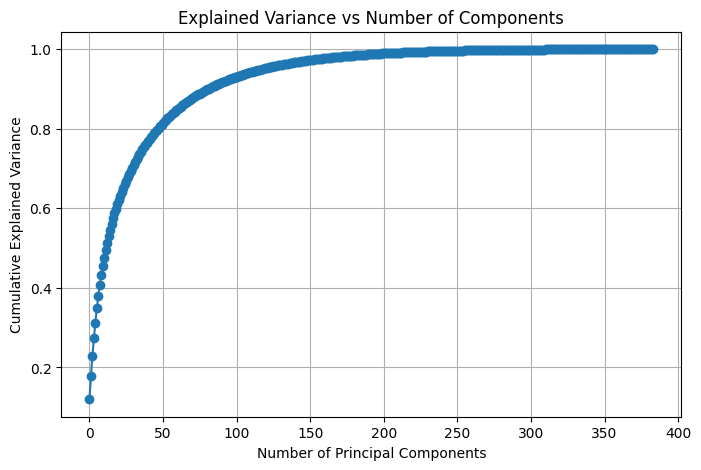

Number of components to reach 99.0% variance: 204


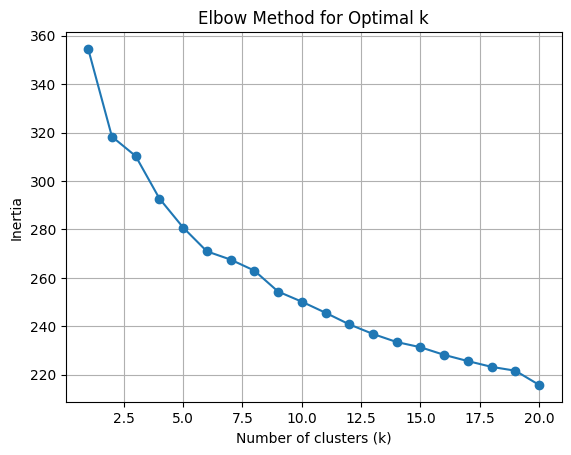

Optimal number of clusters: 9


In [ ]:
metric = 'euclidean'
is_euclidean = metric == 'euclidean'
listInfo(vectors, withL2Normalization=not is_euclidean)

In [ ]:
reduce_dims_umap(df, vectors)
visualize_plot("UMAP", df, "Category")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.




Cluster Formal Logic Category Distribution:
╒══════════════╤═════════╤══════════════╕
│ Category     │   Count │   Percentage │
╞══════════════╪═════════╪══════════════╡
│ Formal Logic │     147 │          100 │
╘══════════════╧═════════╧══════════════╛

Cluster Functions Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Functions  │     124 │          100 │
╘════════════╧═════════╧══════════════╛

Cluster Relations Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Relations  │     125 │          100 │
╘════════════╧═════════╧══════════════╛

Cluster Sets, Proofs, and Induction Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction 

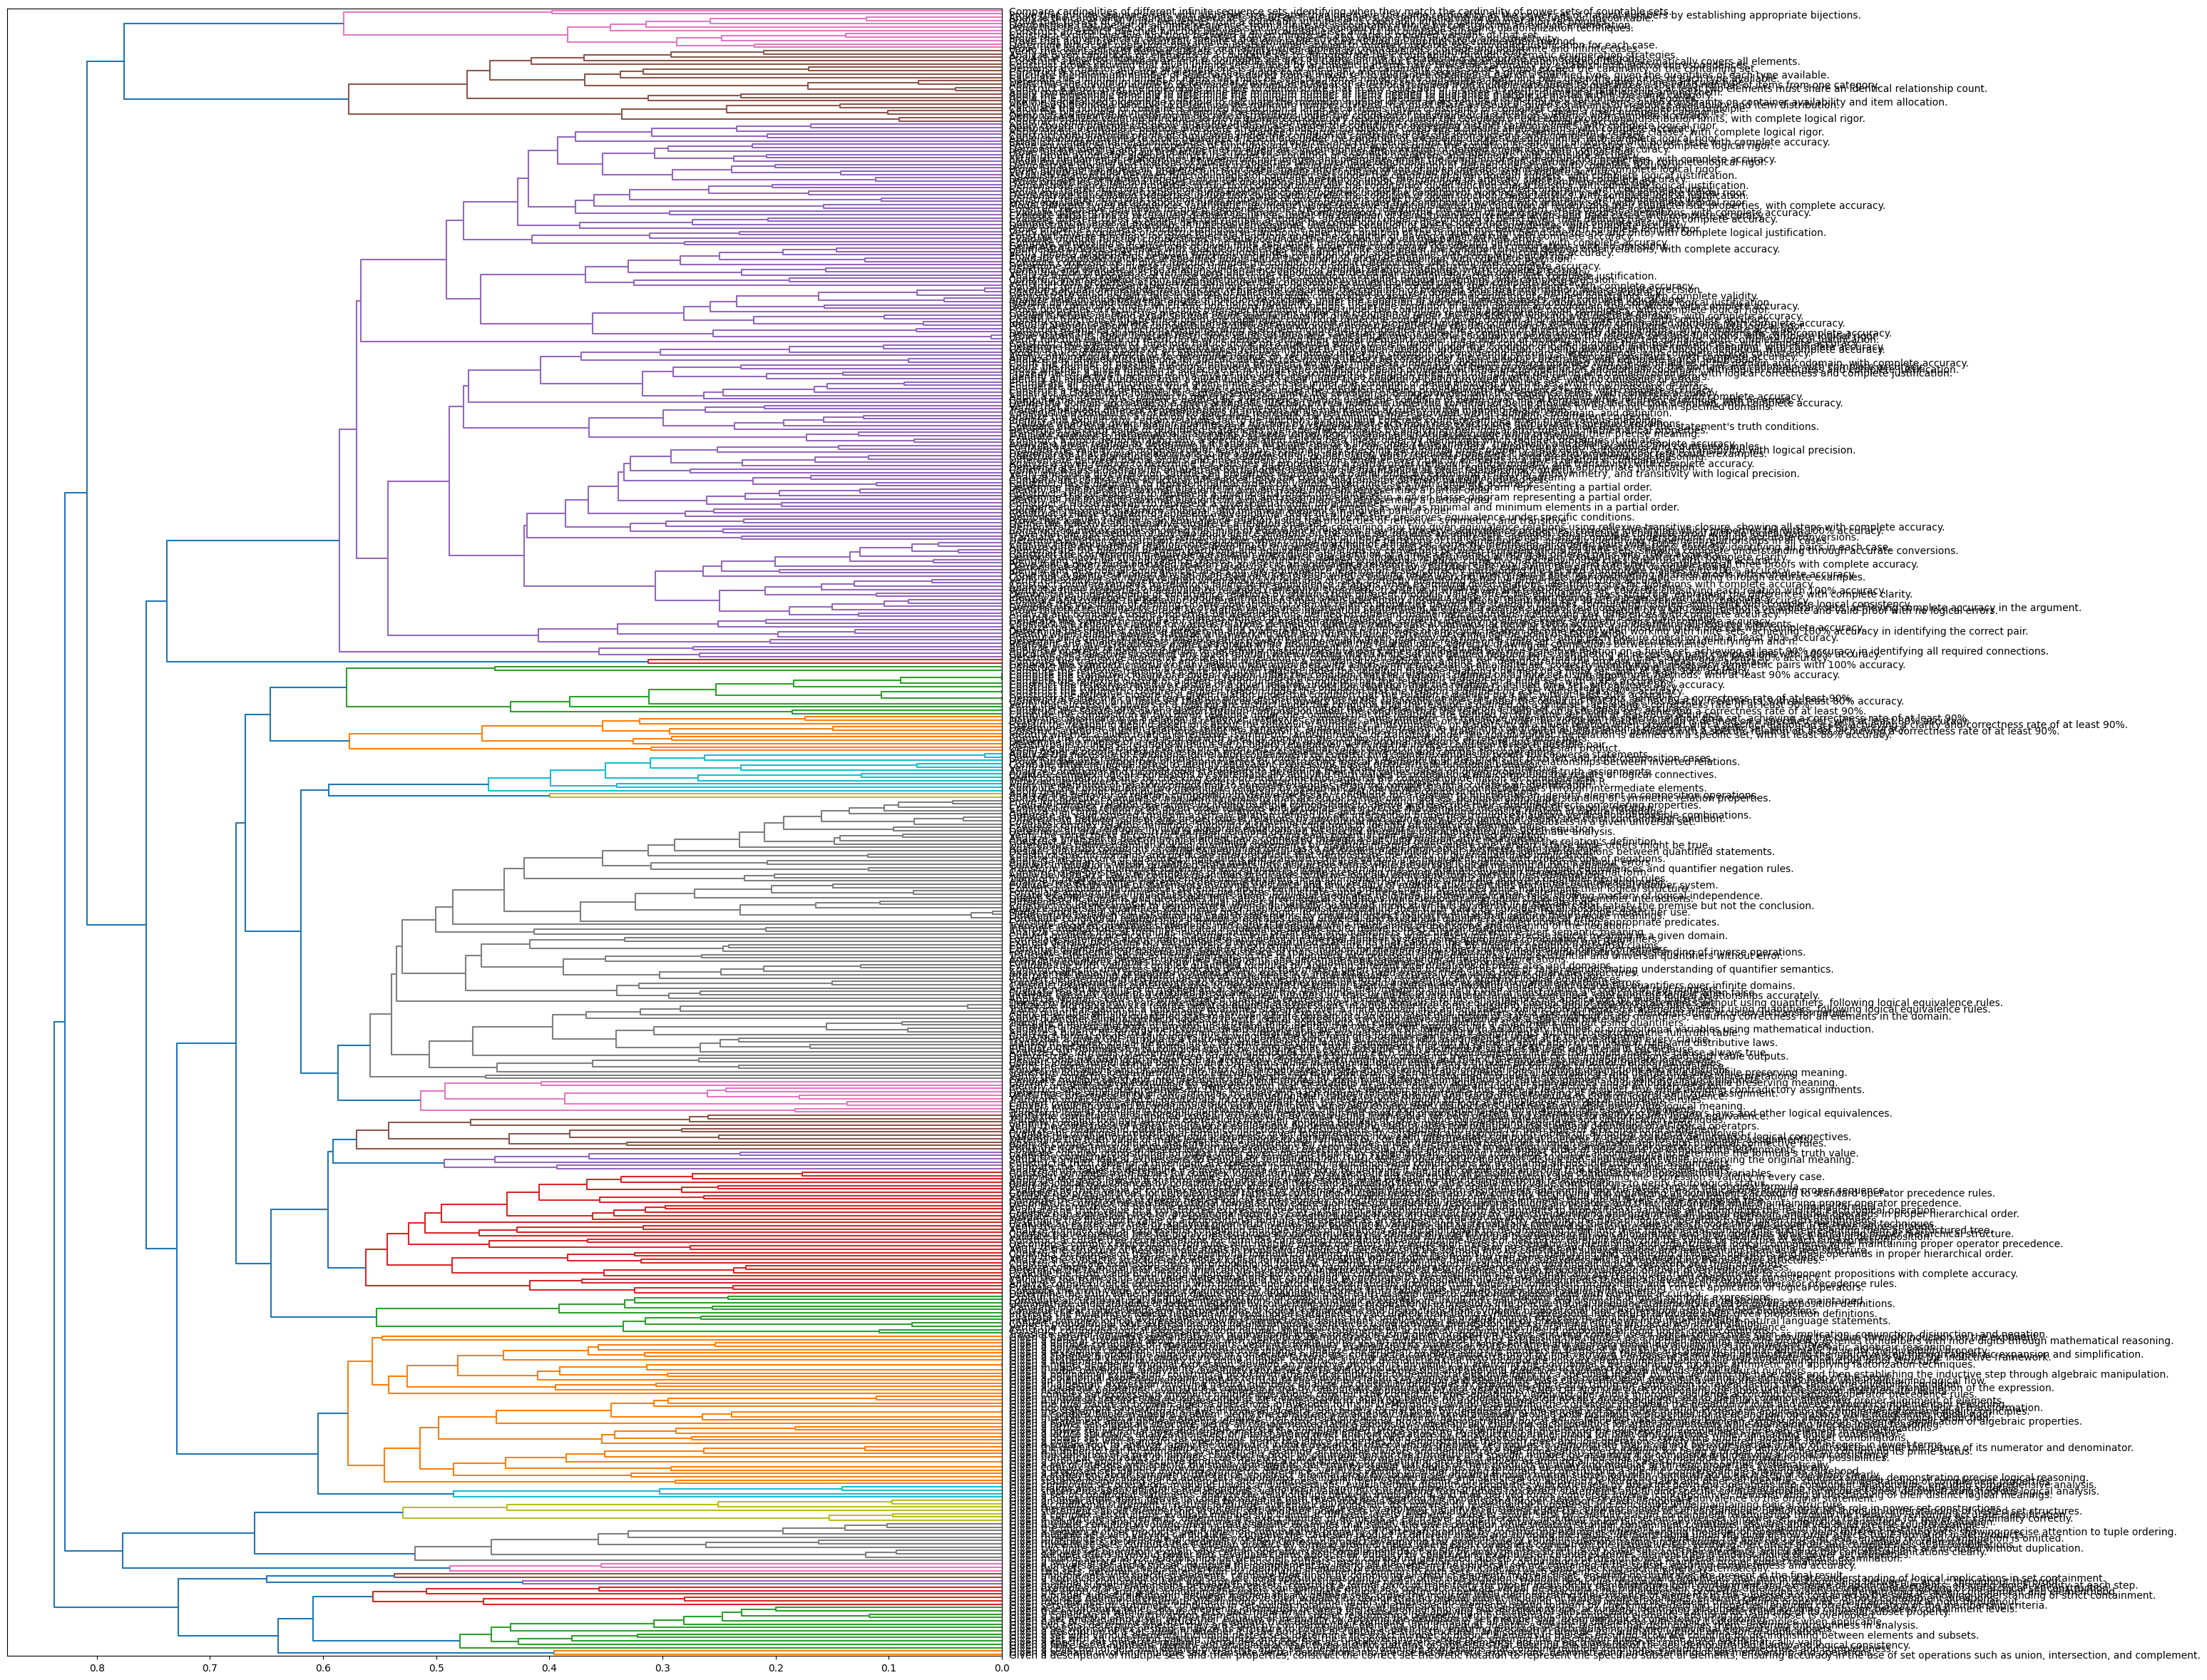

In [ ]:
dendogram = generate_dendrogram_data_euclidean(vectors) if is_euclidean else generate_dendrogram_data_cosine(vectors)
plot_dendrogram(dendogram, df["LO"])

In [ ]:
k = 9
if is_euclidean:
  cluster_all_euclidean(vectors, k, df)
else:
  cluster_all_cosine(vectors, k, df)

create_n_clusters_from_dendogram(df, k, dendogram)
visualize_all_clusters(df)


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │      23 │        56.1  │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │      16 │        39.02 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       1 │         2.44 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       1 │         2.44 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │      43 │        82.69 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and 


Cluster -1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │     119 │        29.02 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │     102 │        24.88 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      96 │        23.41 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      93 │        22.68 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 0 Category Distribution:
╒══════════════╤═════════╤══════════════╕
│ Category     │   Count │   Percentage │
╞══════════════╪═════════╪══════════════╡
│ Formal Logic │       2 │          100 │
╘══════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒══════════════╤═════════╤══════════════╕
│ Category     │  


Cluster -1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │     124 │        32.55 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      96 │        25.2  │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │      87 │        22.83 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │      74 │        19.42 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 0 Category Distribution:
╒══════════════╤═════════╤══════════════╕
│ Category     │   Count │   Percentage │
╞══════════════╪═════════╪══════════════╡
│ Formal Logic │      24 │           96 │
├──────────────┼─────────┼──────────────┤
│ Relations    │       1 │            4 │
╘══════════════╧═════════╧══════════════╛

Cluster 1


Cluster -1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      38 │        55.88 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      24 │        35.29 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       3 │         4.41 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       3 │         4.41 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │     144 │        34.95 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations        


Cluster 0 Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Functions  │      59 │        93.65 │
├────────────┼─────────┼──────────────┤
│ Relations  │       4 │         6.35 │
╘════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Relations  │      69 │        95.83 │
├────────────┼─────────┼──────────────┤
│ Functions  │       3 │         4.17 │
╘════════════╧═════════╧══════════════╛

Cluster 2 Category Distribution:
╒════════════╤═════════╤══════════════╕
│ Category   │   Count │   Percentage │
╞════════════╪═════════╪══════════════╡
│ Functions  │      25 │        96.15 │
├────────────┼─────────┼──────────────┤
│ Relations  │       1 │         3.85 │
╘════════════╧═════════╧══════════════╛

Cluster 3 Category Distribution:
╒═══════════════════════


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │      23 │        56.1  │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │      16 │        39.02 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       1 │         2.44 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       1 │         2.44 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │      43 │        82.69 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and 


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │      23 │           92 │
├─────────────────────────────┼─────────┼──────────────┤
│ Formal Logic                │       2 │            8 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Relations                   │     117 │         58.5 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      63 │         31.5 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │      20 │         10   │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 2 Category 


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │     147 │        29.88 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │     125 │        25.41 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │     124 │        25.2  │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      96 │        19.51 │
╘═════════════════════════════╧═════════╧══════════════╛



Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       6 │          100 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │      13 │        92.86 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       1 │         7.14 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 2 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │       5 │  


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Functions                   │      32 │        78.05 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │       9 │        21.95 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Sets, Proofs, and Induction │      51 │           85 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │       6 │           10 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations                   │       3 │            5 │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 2 Category 

In [ ]:
visualize_plot("hierarchical clustering", df, "h_cluster")


Cluster 0 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Relations                   │     117 │         58.5 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      63 │         31.5 │
├─────────────────────────────┼─────────┼──────────────┤
│ Functions                   │      20 │         10   │
╘═════════════════════════════╧═════════╧══════════════╛

Cluster 1 Category Distribution:
╒═════════════════════════════╤═════════╤══════════════╕
│ Category                    │   Count │   Percentage │
╞═════════════════════════════╪═════════╪══════════════╡
│ Formal Logic                │     143 │        89.38 │
├─────────────────────────────┼─────────┼──────────────┤
│ Sets, Proofs, and Induction │      10 │         6.25 │
├─────────────────────────────┼─────────┼──────────────┤
│ Relations         

In [ ]:
scores = score(vectors, df, metric=metric)
print()
avgs = get_all_average_cluster_purities(df)
print()
w_avgs = get_all_weighted_average_cluster_purities(df)
print()
eval = evaluate_all_clusterings(df, "Category")

avgs.drop(columns=['cluster'])
w_avgs.drop(columns=['cluster'])
eval.drop(columns=['cluster'])

final = pd.concat([scores, avgs[['num_clusters', 'average_purity']], w_avgs[['weighted_average_purity']], eval[['ari', 'nmi', 'v_score']]], axis=1)

final.to_csv("results.csv", index=False)

#files.download("results.csv")

Kmeans Silhouette Score (cosine): 0.1542193591594696
Dbscan Silhouette Score (cosine): 0.7222068309783936
Optics Silhouette Score (cosine): 0.3941444754600525
Hdbscan Silhouette Score (cosine): 0.19817237555980682
Spectral Silhouette Score (cosine): 0.17171692848205566
Gmm Silhouette Score (cosine): 0.1542193591594696
Agglo Silhouette Score (cosine): 0.1886051744222641
Meanshift Silhouette Score (cosine): nan
Affinity Silhouette Score (cosine): 0.18365846574306488
Birch Silhouette Score (cosine): 0.16376277804374695

Averaged purity of cluster_kmeans for 9 clusters : 0.8598353984710835
Averaged purity of cluster_dbscan for 32 clusters excluding noise: 1.0
Averaged purity of cluster_optics for 3 clusters excluding noise: 0.9735947712418301
Averaged purity of cluster_hdbscan for 2 clusters excluding noise: 0.6747572815533981
Averaged purity of cluster_spectral for 9 clusters : 0.8815155124698135
Averaged purity of cluster_gmm for 9 clusters : 0.8598353984710835
Averaged purity of cluster

In [ ]:
weighted_average_cluster_purities(df, 'h_cluster')

Weighted average purity of h_cluster for 9 clusters : 0.7906504065040649


(9, np.float64(0.7906504065040649))

In [ ]:
def export_to_file(df, filename):
  df.to_csv(f"{filename}.csv", index=False)

  files.download(f"{filename}.csv")

In [ ]:
export_to_file(df, "LOs")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>